# Analyze queue occupancy + pcap throughput

For an experiment that has both a **pcap** and a **queue_trace** artifact in telemetry (any run after the `/qtrace` change), this notebook downloads both, prints the iperf3 / curl / etc. output, and plots:

1. Throughput time-series from the pcap
2. Bottleneck queue occupancy from `/qtrace` (packets *and* bytes, one line per interface)
3. Drop rate from `/qtrace`
4. Per-packet size scatter (to spot bursts) — pcap-derived

Set `EXPERIMENT_ID` (cell 2) to the experiment_id printed by the orchestrator.

In [1]:
import os, sys, json
from pathlib import Path

# Make services/analysis importable when opened from repo root or services/.
_here = Path.cwd()
for cand in [_here, _here.parent, _here.parent.parent]:
    if (cand / 'services' / 'analysis' / '__init__.py').exists():
        sys.path.insert(0, str(cand))
        break
    if (cand / 'analysis' / '__init__.py').exists():
        sys.path.insert(0, str(cand))
        break

try:
    from services.analysis import (
        TelemetryClient, print_result_summary, print_qoe_metrics,
        extract_speedtest, extract_iperf, extract_ping,
        load_pcap, filter_downlink, filter_uplink, summarize_pcap,
        plot_throughput, plot_packet_size,
        load_queue_trace, summarize_queue_trace, plot_queue_occupancy, plot_drop_rate,
    )
except ModuleNotFoundError:
    from analysis import (
        TelemetryClient, print_result_summary, print_qoe_metrics,
        extract_speedtest, extract_iperf, extract_ping,
        load_pcap, filter_downlink, filter_uplink, summarize_pcap,
        plot_throughput, plot_packet_size,
        load_queue_trace, summarize_queue_trace, plot_queue_occupancy, plot_drop_rate,
    )

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
EXPERIMENT_ID = os.environ.get('EXPERIMENT_ID', 'wget_10_10_20_pfifo_cubic_0c6d312a')
TELEMETRY_BASE = os.environ.get('TELEMETRY_BASE', 'http://localhost:8004')
OUT_DIR = Path('./_pcap_cache').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'experiment_id  : {EXPERIMENT_ID}')
print(f'telemetry_base : {TELEMETRY_BASE}')
print(f'cache dir      : {OUT_DIR}')

experiment_id  : wget_10_10_100_pfifo_cubic_2f8a6990
telemetry_base : http://localhost:8004
cache dir      : /Users/eugenevuong/Documents/UCSB/agentic-thin-waist/services/analysis/_pcap_cache


## 1. Pull results + artifact list

In [3]:
client = TelemetryClient(TELEMETRY_BASE)
print('telemetry health:', client.health())

bundle = client.fetch_experiment(EXPERIMENT_ID)
print(f'\nfound {len(bundle.results)} result(s) for {EXPERIMENT_ID}')
for r in bundle.results:
    print(f'  - result_id={r.get("result_id")}  trial={r.get("trial_number")}  status={r.get("status")}')
    for a in bundle.artifacts_by_result.get(r['result_id'], []):
        print(f'      artifact: {a.get("artifact_type"):11s}  {a.get("filename")}  ({a.get("size_bytes")} bytes)')

telemetry health: {'message': 'Success'}

found 1 result(s) for wget_10_10_100_pfifo_cubic_2f8a6990
  - result_id=51819c94-cdc8-4970-833b-f1eaa3b7b29b  trial=1  status=success
      artifact: pcap         wget_10_10_100_pfifo_cubic_2f8a6990.pcap  (19967372 bytes)
      artifact: queue_trace  wget_10_10_100_pfifo_cubic_2f8a6990_qtrace.jsonl  (1858671 bytes)


## 2. QoE metrics + raw shell stdout (iperf3 / curl / etc.)

In [4]:
result = bundle.latest
if result is None:
    raise RuntimeError(f'no telemetry rows for {EXPERIMENT_ID}')
result = client.get_result(result['result_id'])
print_result_summary(result)
print()
print_qoe_metrics(result)

for label, fn in [('iperf', extract_iperf), ('speedtest', extract_speedtest), ('ping', extract_ping)]:
    extracted = fn(result)
    if extracted:
        print(f'\n[{label}]')
        for k, v in extracted.items():
            print(f'  {k}: {v}')

qoe = result.get('qoe_metrics') or []
if isinstance(qoe, list) and qoe and isinstance(qoe[0], dict) and 'stdout' in qoe[0]:
    print('\n--- raw stdout (first action) ---')
    print(qoe[0]['stdout'][:4000])

result_id      : 51819c94-cdc8-4970-833b-f1eaa3b7b29b
experiment_id  : wget_10_10_100_pfifo_cubic_2f8a6990
trial_number   : 1
status         : success
created_at     : 2026-05-19T23:27:47.490836Z

contextual_tree:
  c_static:
    buffer_packets: 1000
    capacity_mbps: 10.0
    latency_ms: 100.0
    qdisc: pfifo
    upload_mbps: 10.0
  c_dyn:
    (empty)
  c_app:
    application: shell
  c_trans:
    congestion_control: cubic
    runtime: shell

qoe_metrics:
{
  "result": [
    {
      "error": "Action 'wget' failed: wget exited with a non-zero status | returncode=124 | cmd=nsenter -t 1 -m -- ip netns exec ns1 wget --no-verbose -O /dev/null --timeout 30 --tries 1 https://releases.ubuntu.com/26.04/ubuntu-26.04-desktop-amd64.iso | stderr=[terminated at experiment-duration deadline]",
      "success": false
    }
  ],
  "runtime": "shell",
  "status": "ok",
  "terminated_at_deadline": true
}


## 3. Download pcap + queue_trace

In [5]:
pcap_paths = client.download_pcaps(bundle, OUT_DIR, result_id=result['result_id'])
qtrace_paths = client.download_qtraces(bundle, OUT_DIR, result_id=result['result_id'])

print('pcap files     :', pcap_paths)
print('qtrace files   :', qtrace_paths)

pcap_path = pcap_paths[0] if pcap_paths else None
qtrace_path = qtrace_paths[0] if qtrace_paths else None

if pcap_path:
    pkts = load_pcap(pcap_path)
    pkts_down = filter_downlink(pkts)
    pkts_up = filter_uplink(pkts)
    print('pcap summary (all)    :', summarize_pcap(pkts))
    print('pcap summary (download):', summarize_pcap(pkts_down))
    print('pcap summary (upload)  :', summarize_pcap(pkts_up))
else:
    pkts = None
    pkts_down = None
    pkts_up = None
    print('(no pcap artifact)')

if qtrace_path:
    df = load_queue_trace(qtrace_path)
    print(f'qtrace samples : {len(df)}  ({df["iface"].nunique()} interfaces)')
    print('summary by iface:')
    summary = summarize_queue_trace(df)
    print(json.dumps(summary, indent=2))
else:
    df = None
    print('(no queue_trace artifact — was the experiment run before /qtrace was added?)')

pcap files     : [PosixPath('/Users/eugenevuong/Documents/UCSB/agentic-thin-waist/services/analysis/_pcap_cache/wget_10_10_100_pfifo_cubic_2f8a6990.pcap')]
qtrace files   : [PosixPath('/Users/eugenevuong/Documents/UCSB/agentic-thin-waist/services/analysis/_pcap_cache/wget_10_10_100_pfifo_cubic_2f8a6990_qtrace.jsonl')]


pcap summary (all)    : {'packets': 3581, 'total_bytes': 19845350, 'duration_s': 29.327970027923584, 'avg_throughput_mbps': 5.41335795995562, 'protocols': {'tcp': 3557, 'udp': 7, 'icmp': 10, 'other': 7}, 'tcp_flows': 5}
pcap summary (download): {'packets': 1912, 'total_bytes': 13213362, 'duration_s': 29.32787013053894, 'avg_throughput_mbps': 3.6043154695344897, 'protocols': {'tcp': 1904, 'udp': 3, 'icmp': 5, 'other': 0}, 'tcp_flows': 5}
pcap summary (upload)  : {'packets': 1662, 'total_bytes': 6631554, 'duration_s': 29.321955919265747, 'avg_throughput_mbps': 1.8093074058931498, 'protocols': {'tcp': 1653, 'udp': 4, 'icmp': 5, 'other': 0}, 'tcp_flows': 5}
qtrace samples : 12002  (2 interfaces)
summary by iface:
{
  "veth2": {
    "samples": 6001,
    "duration_s": 29.997393131256104,
    "backlog_pkts": {
      "min": 0.0,
      "mean": 62.82492879879377,
      "p50": 0.0,
      "p95": 483.0,
      "p99": 513.0,
      "max": 526.0
    },
    "backlog_bytes": {
      "min": 0.0,
      "me

## 4. Side-by-side plots

Row 1: pcap throughput — left panel is **download** traffic, right panel is **upload** traffic. Row 2: queue occupancy in packets. Row 3: drop rate.

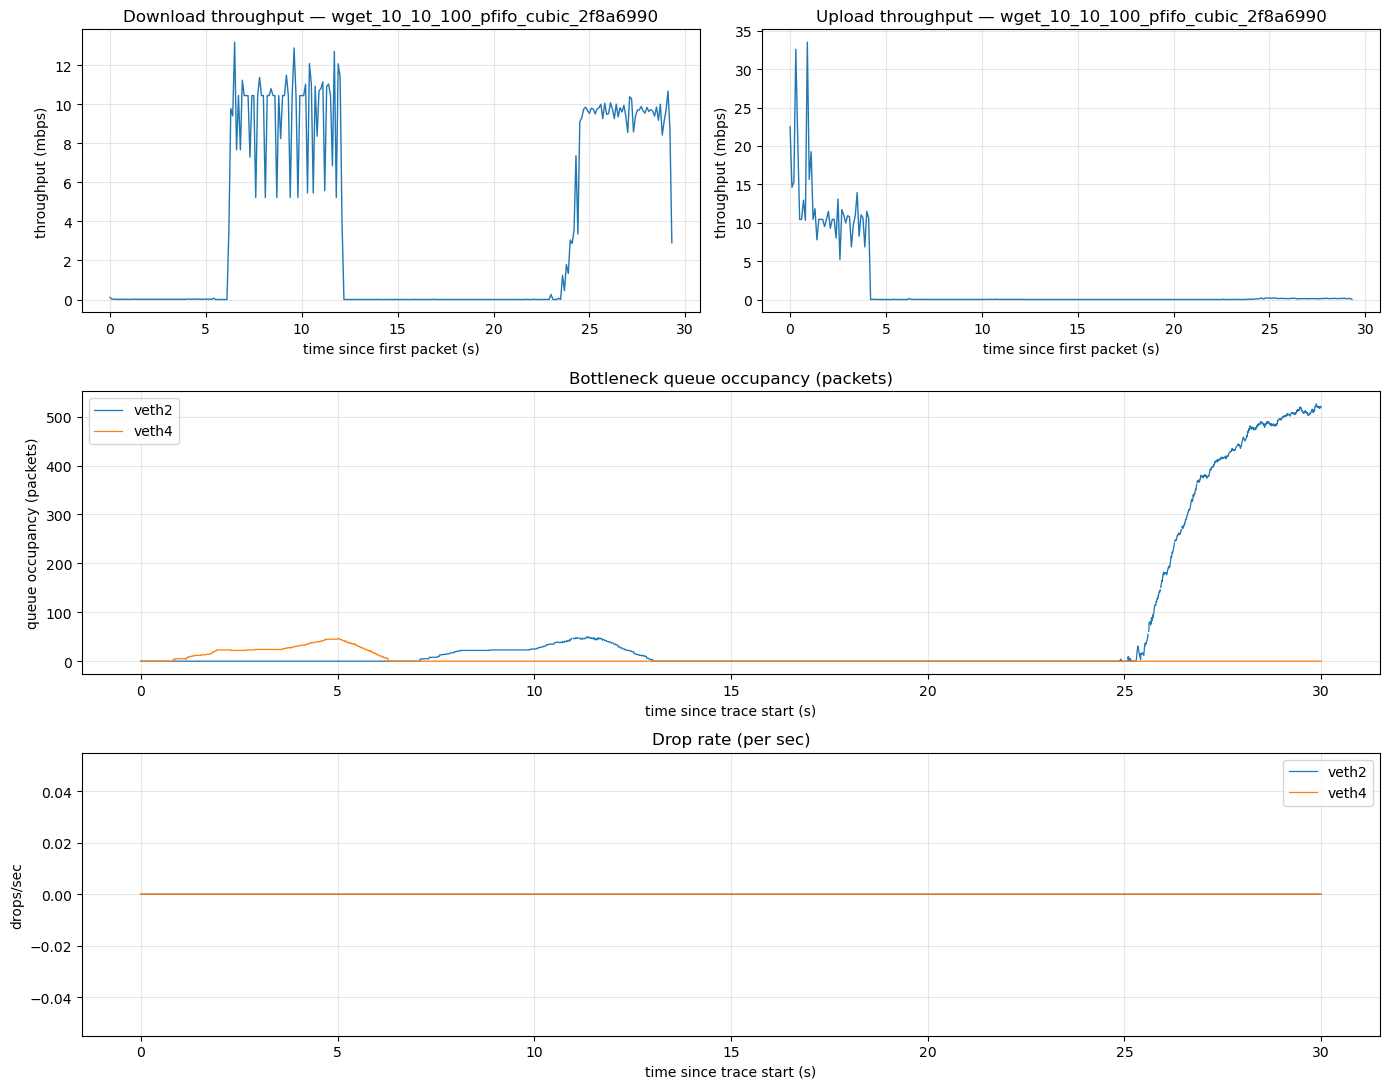

In [6]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 11))
gs = gridspec.GridSpec(3, 2, figure=fig)
ax_thr_down = fig.add_subplot(gs[0, 0])
ax_thr_up = fig.add_subplot(gs[0, 1], sharex=ax_thr_down)
ax_queue = fig.add_subplot(gs[1, :])
ax_drop = fig.add_subplot(gs[2, :])

if pkts_down is not None:
    plot_throughput(pkts_down, bin_seconds=0.1, unit='mbps', ax=ax_thr_down,
                    title=f'Download throughput — {EXPERIMENT_ID}')
else:
    ax_thr_down.set_title('(no pcap)')
    ax_thr_down.axis('off')

if pkts_up is not None:
    plot_throughput(pkts_up, bin_seconds=0.1, unit='mbps', ax=ax_thr_up,
                    title=f'Upload throughput — {EXPERIMENT_ID}')
else:
    ax_thr_up.set_title('(no pcap)')
    ax_thr_up.axis('off')

if df is not None and not df.empty:
    plot_queue_occupancy(df, unit='packets', ax=ax_queue,
                         title='Bottleneck queue occupancy (packets)')
    plot_drop_rate(df, ax=ax_drop, title='Drop rate (per sec)')
else:
    ax_queue.set_title('(no queue_trace)')
    ax_queue.axis('off')
    ax_drop.set_title('(no queue_trace)')
    ax_drop.axis('off')

# Keep the legacy `axes` name so downstream cells still work.
axes = [ax_thr_down, ax_queue, ax_drop]

plt.tight_layout()
# axes[1].set_yscale('log')
# axes[1].set_ylim(0,50)
plt.show()

<Figure size 640x480 with 0 Axes>

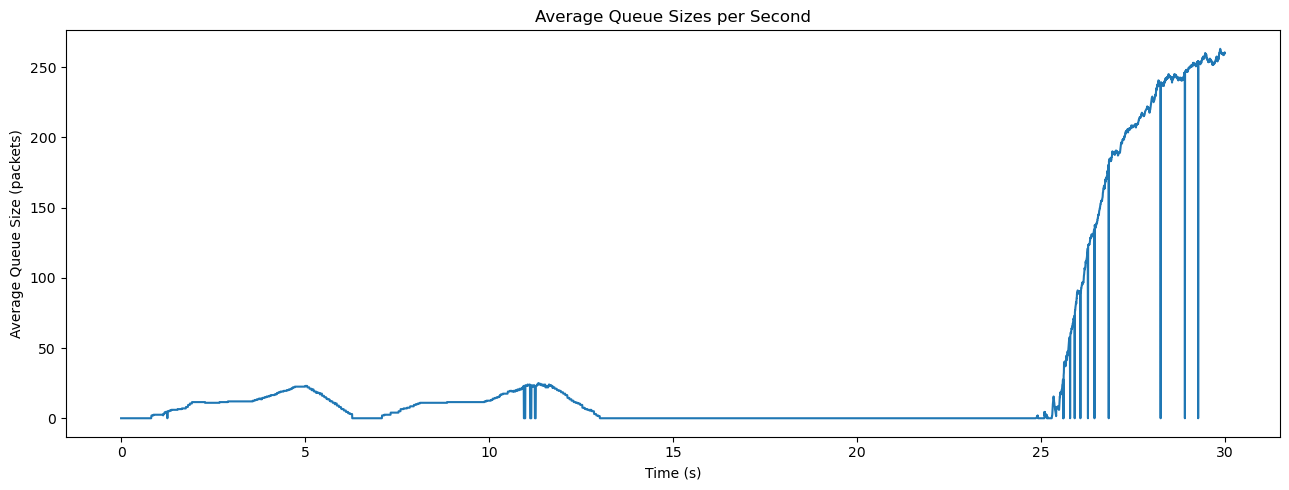

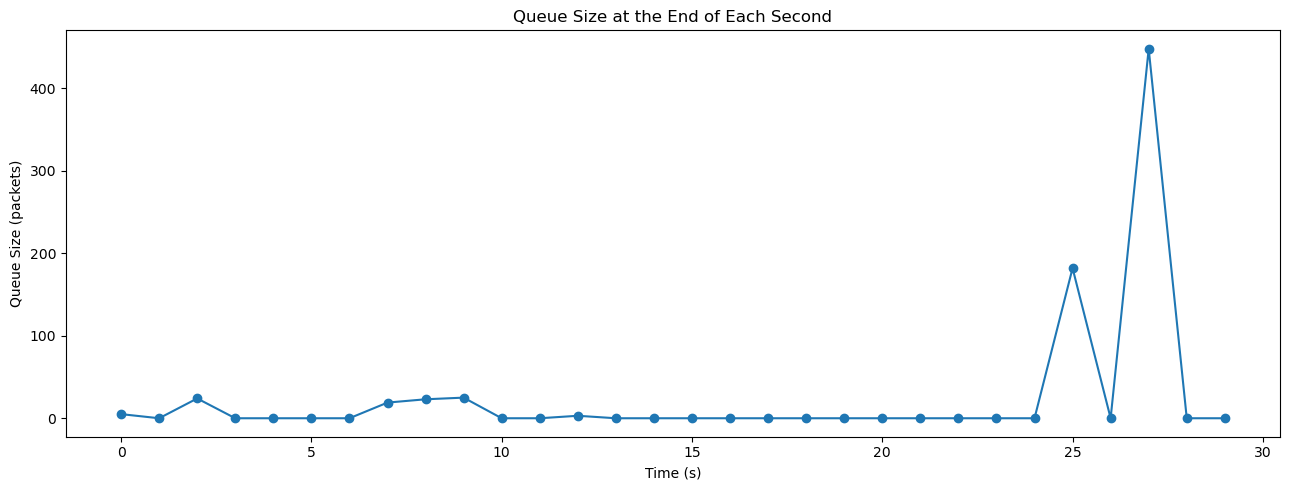

In [7]:
if pkts_down is not None:
    plot_throughput(pkts_down, bin_seconds=0.1, unit='mbps', ax=axes[0],
                    title=f'Download throughput — {EXPERIMENT_ID}')
else:
    axes[0].set_title('(no pcap)')
    axes[0].axis('off')

if df is not None and not df.empty:
    plot_queue_occupancy(df, unit='packets', ax=axes[1],
                         title='Bottleneck queue occupancy (packets)')
    plot_drop_rate(df, ax=axes[2], title='Drop rate (per sec)')
else:
    axes[1].set_title('(no queue_trace)')
    axes[1].axis('off')
    axes[2].set_title('(no queue_trace)')
    axes[2].axis('off')

plt.tight_layout()
# axes[1].set_yscale('log')
axes[1].set_ylim(0,50)
if df is not None and not df.empty:
    qsizes = df.groupby('rel_t')['backlog_pkts'].mean()
    fig, ax = plt.subplots(figsize=(13, 5))
    qsizes.plot(ax=ax, title='Average Queue Sizes per Second', xlabel='Time (s)', ylabel='Average Queue Size (packets)')
    plt.tight_layout()
    plt.show()
else:
    print('No queue_trace artifact to plot.')

# instead of plotting the mean, plot the sample at the end of each second
if df is not None and not df.empty:
    # Get the last sample for each second
    df['second'] = df['rel_t'].astype(int)
    last_samples = df.groupby('second').last().reset_index()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(last_samples['second'], last_samples['backlog_pkts'], marker='o')
    ax.set_title('Queue Size at the End of Each Second')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Queue Size (packets)')
    plt.tight_layout()
    plt.show()

## 5. CCAnalyzer-style queue evolution

Zoom in on a window of interest and look at queue occupancy in bytes. Reno's sawtooth, Cubic's $x^3$ curve, and BBR's periodic bandwidth probes show up clearly here.

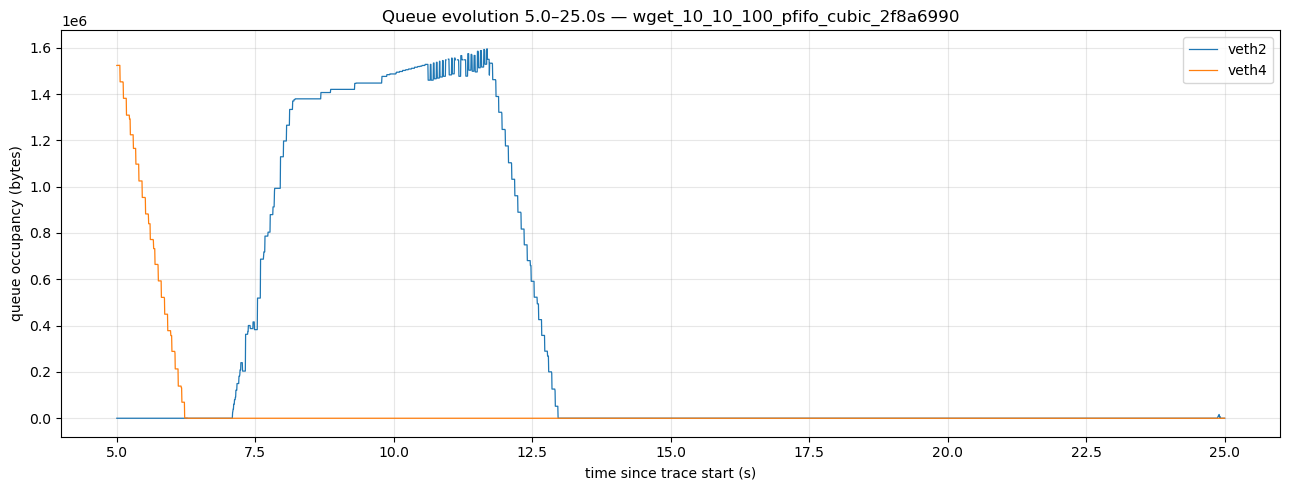

In [8]:
if df is not None and not df.empty:
    # Default: zoom into the second 5 seconds (skip the slow-start ramp).
    t_min, t_max = float(os.environ.get('QTRACE_T_MIN', 5)), float(os.environ.get('QTRACE_T_MAX', 25))
    sub = df[(df['rel_t'] >= t_min) & (df['rel_t'] <= t_max)]
    fig, ax = plt.subplots(figsize=(13, 5))
    plot_queue_occupancy(sub, unit='bytes', ax=ax,
                         title=f'Queue evolution {t_min:.1f}–{t_max:.1f}s — {EXPERIMENT_ID}')
    plt.tight_layout()
    plt.show()
else:
    print('No queue_trace artifact to plot.')

## 6. (Optional) repeat across trials

In [9]:
for res in bundle.results:
    rid = res['result_id']
    full = client.get_result(rid)
    print('=' * 80)
    print(f'result_id={rid}  trial={res.get("trial_number")}  status={res.get("status")}')
    extracted = extract_iperf(full) or extract_speedtest(full) or extract_ping(full)
    if extracted:
        for k, v in extracted.items():
            print(f'  {k}: {v}')
    qpaths = client.download_qtraces(bundle, OUT_DIR, result_id=rid)
    if not qpaths:
        print('  (no qtrace)')
        continue
    qdf = load_queue_trace(qpaths[0])
    print('  qtrace summary:', json.dumps(summarize_queue_trace(qdf), indent=2))

result_id=51819c94-cdc8-4970-833b-f1eaa3b7b29b  trial=1  status=success
  qtrace summary: {
  "veth2": {
    "samples": 6001,
    "duration_s": 29.997393131256104,
    "backlog_pkts": {
      "min": 0.0,
      "mean": 62.82492879879377,
      "p50": 0.0,
      "p95": 483.0,
      "p99": 513.0,
      "max": 526.0
    },
    "backlog_bytes": {
      "min": 0.0,
      "mean": 464360.68018093484,
      "p95": 1881930.0,
      "max": 1905880.0
    },
    "total_drops": 0,
    "mean_throughput_mbps": 3.679361854742369
  },
  "veth4": {
    "samples": 6001,
    "duration_s": 29.997393131256104,
    "backlog_pkts": {
      "min": 0.0,
      "mean": 4.496333333333333,
      "p50": 0.0,
      "p95": 31.0,
      "p99": 45.0,
      "max": 46.0
    },
    "backlog_bytes": {
      "min": 0.0,
      "mean": 200674.30716666667,
      "p95": 1436856.0,
      "max": 1523817.0
    },
    "total_drops": 0,
    "mean_throughput_mbps": 1.866616817013228
  }
}
